# 2.17. Computer Code for Plane Problems using Quadratic Elements (QUADPLEH)

A FORTRAN code that uses (QUA)dratic elements for the solution of (D)ynamic (PL)ane (E)lastic time-(H)armonic problems is described next.

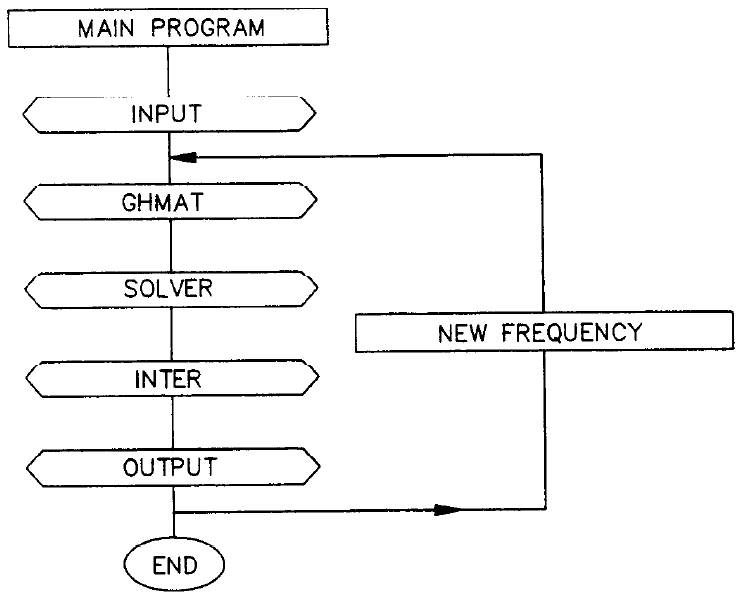

# Download `quadpleh` from `Github`

In [ ]:
!git clone https://github.com/e-albuquerque/BEM_frequency_domain_2D.git

Cloning into 'BEM_frequency_domain_2D'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 17 (delta 3), reused 17 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 19.83 KiB | 6.61 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
ls

BEM_frequency_domain_2D/  sample_data/


In [ ]:
cd BEM_frequency_domain_2D/

/content/BEM_frequency_domain_2D


In [ ]:
ls

assembly_mod.f90  data_mod.f90  Makefile   preproc.py    solver_mod.f90
bessel_mod.f90    io_mod.f90    placa.geo  quadpleh.for  squa4.dat
build.bat         main.f90      placa.msh  README.md


# Build executable `quadpleh_modern.exe`

In [ ]:
!make

gfortran -O3 -fopenmp -c data_mod.f90
gfortran -O3 -fopenmp -c bessel_mod.f90
gfortran -O3 -fopenmp -c solver_mod.f90
gfortran -O3 -fopenmp -c assembly_mod.f90
assembly_mod.f90:22:20:

   22 |    11 H(I,J)=(0.,0.)
      |                    1
assembly_mod.f90:24:20:

   24 |    12 G(I,J)=(0.,0.)
      |                    1
assembly_mod.f90:35:54:

   35 |       IF((LL-I)*(LL-I-1)*(LL-I-2)*(LL-I+N-2)) 22,21,22
      |                                                      1
assembly_mod.f90:54:18:

   54 |       DO 70 JC=1,2
      |                  1
assembly_mod.f90:83:43:

   83 |       IF(REAL(H(2*LL-1,2*LL-1))) 95,100,100
      |                                           1
assembly_mod.f90:94:35:

   94 |       IF(KODE(6*I-6+J)) 110,110,170
      |                                   1
assembly_mod.f90:96:31:

   96 |       IF(KODE(J-4)) 115,115,113
      |                               1
assembly_mod.f90:100:22:

  100 |   114 G(K,6*I-6+J)=-CH
      |                      1
assembly_

In [ ]:
ls

assembly_mod.f90  build.bat     io_mod.o   preproc.py            solver_mod.o
assembly_mod.mod  data_mod.f90  main.f90   quadpleh.for          squa4.dat
assembly_mod.o    data_mod.mod  main.o     quadpleh_modern.exe*
bessel_mod.f90    data_mod.o    Makefile   README.md
bessel_mod.mod    io_mod.f90    placa.geo  solver_mod.f90
bessel_mod.o      io_mod.mod    placa.msh  solver_mod.mod


# Install meshio

In [ ]:
!pip install meshio[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.7 MB/s eta 0:00:00


# Install Gmsh

In [ ]:
!apt-get update
!apt-get install gmsh
!python -m pip install gmsh

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:12 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1,943 kB]
Get:13 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1,688 kB]
Get:1

# Gmsh geometry file (```.geo```)

In [ ]:
%%writefile placa.geo
ref=1.;
L=6.;
Point(1) = {0, 0, 0, ref};
Point(2) = {L, 0, 0, ref};
Point(3) = {L, L, 0, ref};
Point(4) = {0, L, 0, ref};
Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line Loop(1) = {1, 2, 3, 4};
Plane Surface(1) = {1};
Physical Curve("botton") = {1};
Physical Curve("right") = {2};
Physical Curve("top") = {3};
Physical Curve("left") = {4};
Physical Surface("surf1") = {1};

Overwriting placa.geo


# Generate mesh file (```.msh```) using Gmsh

In [ ]:
!gmsh -1  placa.geo -o placa.msh  -order 2

Info    : Running '/usr/local/bin/gmsh -1 placa.geo -o placa.msh -order 2' [Gmsh 4.15.2, 1 node, max. 1 thread]
Info    : Started on Fri Oct  2 11:28:03 2026
Info    : Reading 'placa.geo'...
Info    : Done reading 'placa.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.00060424s, CPU 0.000449s)
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 30%] Meshing curve 2 order 2
Info    : [ 50%] Meshing curve 3 order 2
Info    : [ 70%] Meshing curve 4 order 2
Info    : [ 90%] Meshing surface 1 order 2
Info    : Done meshing order 2 (Wall 0.000365524s, CPU 0.000279s)
Info    : 48 nodes 28 elements
Info    : Writing 'placa.msh'...
Info    : Done writing 'placa.msh'
Info    : Stopped on Fri Oct  2 11:28:03 2026 (From start: Wall 0.00465386s, CPU 0.22284s)


# Generate input data for the Fortran analysis

In [ ]:
import numpy as np
import meshio

def input_data():
    """
    This function defines input parameters for the Boundary Element Method (BEM)
    simulation applied to the plane elasticity equation with radial integration for domain
    integrals.

    Returns:
        dict: A dictionary containing the following key-value pairs:
            * bound_cond (dict): Boundary conditions for each edge:
                *
            * E (float): Material elastic modulus
            * nu (float): Poisson's ratio
            * file_name (str): Name of the .msh file (Gmsh mesh)
            * qpoint (str): String representing the coordinates of the heat source point
    """
    # Directly define values here for scripting (modify as needed)
    # Boundary conditions are specified in local coordinate system (normal-tangent)
    # type_x = type of the boundary condition in x direction
    # type_y = type of the boundary condition in y direction
    #    (type_x and type_y: 0 = displacement is know while 1 = traction is known)

    bound_cond = {'botton': {'type_x': 1, 'value_x': [0,0], 'type_y': 0, 'value_y': [0,0]},
                  'right': {'type_x': 0, 'value_x': [0,0], 'type_y': 1, 'value_y': [0,0]},
        'top': {'type_x': 1, 'value_x': [0,0], 'type_y': 1, 'value_y': [100,0]},
        'left': {'type_x': 0, 'value_x': [0,0], 'type_y': 1, 'value_y': [0,0]}
    }
    E = 200.0e9 # # Elastic modulus
    nu = 0.3 # Poisson ration
    file_name = 'placa'
    rho = 7850 # density
    damp = 0.05 # damping

    return {'bound_cond': bound_cond, 'E': E, 'nu': nu, 'file_name': file_name,\
            'rho' : rho, 'damp' : damp}

In [ ]:
# Read information about input data
inp_data = input_data()

In [ ]:
def compute_inodes(file_name, bound_cond):
    """
    This function reads a mesh file and extracts information about nodes, elements,
    and boundary conditions.

    Args:
      file_name: Name of the mesh file.
      bound_cond: Dictionary containing boundary conditions for each edge.

    Returns:
      A dictionary containing information about nodes, elements, and boundary
      conditions.
    """
    mesh = meshio.read(file_name + '.msh')
    coordinates = mesh.points
    line_elements = mesh.cells_dict['line3']
    segments = mesh.cell_data_dict['gmsh:physical']['line3']

    bc_info = {}
    for key, value in bound_cond.items():
        segment = mesh.field_data[key][0]
        bc_info[key] = {
            'type_x': value['type_x'],
            'value_x': value['value_x'],
            'segment': segment,
            'type_y': value['type_y'],
            'value_y': value['value_y']
        }

    boundary_nodes = np.unique(line_elements)

    return {
        'nodes': boundary_nodes,
        'coordinates': coordinates,
        'elements': line_elements,
        'segments': segments,
        'bc_info': bc_info
    }

In [ ]:
# Format input data
computed_data = compute_inodes(inp_data['file_name'], inp_data['bound_cond'])

In [ ]:
def compute_n(xi, x1, y1, x2, y2, x3, y3):
    """
    Computes the Jacobian, normal vector, and tangent vector at a point on the quadratic element.

    Args:
        xi (float): Gauss point in the local coordinate system.
        x1, y1, x2, y2, x3, y3: Coordinates of the nodes of the quadratic element.

    Returns:
        nx, ny (float): Components of the unit normal vector.
        dgamadxi (float): Magnitude of the Jacobian.
    """
    # Shape function derivatives
    dN1dxi = -1 / 2 + xi
    dN2dxi = -2 * xi
    dN3dxi = 1 / 2 + xi

    # Derivatives of x and y with respect to xi
    dxdxi = dN1dxi * x1 + dN2dxi * x2 + dN3dxi * x3
    dydxi = dN1dxi * y1 + dN2dxi * y2 + dN3dxi * y3

    # Jacobian magnitude
    dgamadxi = np.sqrt(dxdxi**2 + dydxi**2)

    # Tangent and normal vectors
    sx, sy = dxdxi / dgamadxi, dydxi / dgamadxi
    nx, ny = sy, -sx  # Rotate tangent by 90 degrees to get normal

    return nx, ny

In [ ]:
def mount_bcs(segments, bc_info):
    """
    Constructs a boundary condition matrix from segment information and boundary condition data.

    This function takes a list of segment indices (`segments`) and a dictionary of boundary condition
    information (`bc_info`) to create a matrix (`bcs`) that stores the type and value of the boundary
    condition for each element.

    Args:
        segments (list or np.ndarray): A list or array of integers representing the indices of the boundary
                                       elements (segments) in the problem.
        bc_info (dict): A dictionary containing boundary condition information. The keys are typically
                        strings representing boundary condition names, and the values are dictionaries
                        with the following structure:
                        {
                            'type_x': bc_type,     # The type of boundary condition in x (0 for Dirichlet, 1 for Neumann)
                            'value_x': bc_value    # The value of the boundary condition in x (displacement or traction)
                            'segment': segment_index,  # The index of the segment this BC applies to
                            'type_y': bc_type,          # The type of boundary condition in y (0 for Dirichlet, 1 for Neumann)
                            'value_y': bc_value         # The value of the boundary condition in y (displacement or traction)
                        }

    Returns:
        bcs (np.ndarray): A 2D NumPy array where each row corresponds to a boundary element. The first
                         and third column contains the boundary condition type (0 or 1), and the second
                         and fourth column contains the boundary condition value.
    """

    num_elements = len(segments)

    # Initialize boundary condition matrix
    type_bcs = np.zeros((num_elements, 6), dtype=np.int64)
    val_bcs = np.zeros((num_elements, 6), dtype=np.complex64)

    # Populate boundary condition matrix (bcs)
    for i, segment_index in enumerate(segments):
        # Find the boundary condition data corresponding to the current segment
        for bc_name, bc_data in bc_info.items():
            if bc_data['segment'] == segment_index:
                tp_x=bc_data['type_x']
                vl_xr= bc_data['value_x'][0]
                vl_xi= bc_data['value_x'][1]
                tp_y=bc_data['type_y']
                vl_yr= bc_data['value_y'][0]
                vl_yi= bc_data['value_y'][1]
                vx = vl_xr + 1j * vl_xi
                vy = vl_yr + 1j * vl_yi
                type_bcs[i,:] = np.array([tp_x,tp_y,tp_x,tp_y,tp_x,tp_y])
                val_bcs[i,:] = np.array([vx,vy,vx,vy,vx,vy])
                break  # Move on to the next segment once the BC is found
    return type_bcs,val_bcs

def comp_normal(elem, nodes):
    """
    Calculates the nodes and outward normal vector for each boundary element.

    This function takes element connectivity information (`elem`) and node coordinates (`nodes`)
    to determine the geometric center of each boundary element and the unit normal vector
    pointing outward from that element.

    Args:
        elem (np.ndarray): A 2D array defining the connectivity of the boundary elements.
                          Each row contains the indices of the two nodes that form an element.
                          Shape: (num_elements, 2).
        nodes (np.ndarray): A 2D array containing the coordinates (x, y) of each node in the mesh.
                           Shape: (num_nodes, 2).

    Returns:
        node_des (np.ndarray): A 2D array containing the coordinates (x, y) of the discontinuous nodes
                              of each boundary element. Shape: (2*num_elements, 2).
        normal (np.ndarray): A 2D array containing the unit outward normal vectors for each
                             boundary element. Shape: (num_elements, 2).
    """
    npp = 8                              # Number of plot points
    eta = np.linspace(-1., 1., npp)        # Plot points

    num_elements = elem.shape[0]

    xplot = np.zeros((num_elements,npp))        # Store x-coordinates for plotting
    yplot = np.zeros((num_elements,npp))        # Store y-coordinates for plotting


    # Initialize arrays to store results

    normal = np.zeros((num_elements, 6))   # Outward normal vectors

    # Define the local coordinates (xi) for nodes within a quadratic element
    xi = np.array([-1., 0., 1.])  # Gauss-Lobatto points for quadratic elements

    # Iterate over each boundary element
    for i in range(num_elements):
        # Get node indices for the current element
        node1, node3, node2 = elem[i]

        # Get coordinates of the two nodes forming the element
        x1, y1 = nodes[node1][0:2]
        x2, y2 = nodes[node2][0:2]
        x3, y3 = nodes[node3][0:2]

        # Calculate and store the normal at the first node (xi = -2/3)
        nx1, ny1 = compute_n(-1., x1, y1, x2, y2, x3, y3)


        # Calculate and store the normal at the second node (xi = 0)
        nx2, ny2 = compute_n(0, x1, y1, x2, y2, x3, y3)


        # Calculate and store the normal at the third node (xi = 1)
        nx3, ny3 = compute_n(1, x1, y1, x2, y2, x3, y3)


        normal[i , :] = [nx1, ny1, nx2, ny2, nx3, ny3]

        # Iterate over Gauss points for numerical integration
        for k in range(npp):
            # Shape functions and their derivatives
            N1 = 0.5 * eta[k] * (eta[k] - 1)
            N2 = 1 - eta[k]**2
            N3 = 0.5 * eta[k] * (eta[k] + 1)

            # Calculate coordinates and normal vector at the Gauss point
            x, y = N1 * x1 + N2 * x2 + N3 * x3, N1 * y1 + N2 * y2 + N3 * y3
            ivet = npp * i + k  # Index for storing plot coordinates
            xplot[i,k], yplot[i,k] = x, y

    return normal,xplot,yplot

In [ ]:
normal,xplot,yplot = comp_normal(computed_data['elements'], computed_data['coordinates'])


# Generate bcs array with boundary conditions in each element
type_bcs,val_bcs = mount_bcs(computed_data['segments'], computed_data['bc_info'])

In [ ]:
def show_geometry(nodes,xplot,yplot,elem):
    xnode=nodes[:,0]
    ynode=nodes[:,1]
    ax = plt.axes()
    plt.plot(xnode[elem[:,0]],ynode[elem[:,0]],"gd",markersize=8)	# Plot the node of the elements
    plt.plot(xnode,ynode,"ro",markersize=2)	# Plot the node of the elements
    plt.axis("equal")

    n_el = elem.shape[0]
    for i in range(n_el):
        x=xplot[i,:]
        y=yplot[i,:]
        line_segments = LineCollection([list(zip(x, y))],
                                        linestyles='solid')
        ax.add_collection(line_segments)

    plt.show()

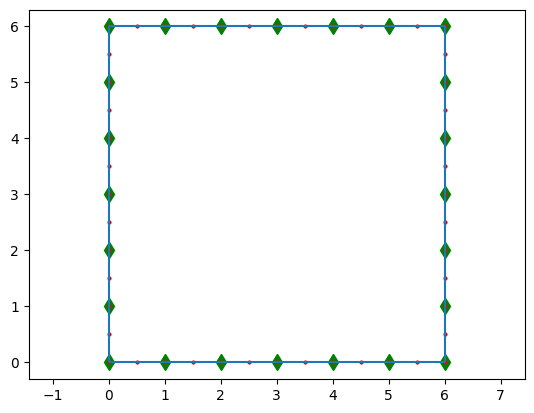

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
show_geometry(computed_data['coordinates'],xplot,yplot,computed_data['elements'],)

In [ ]:
frequencies = [10., 40., 70.]


In [ ]:
import numpy as np

# Re-get the global `inp_data` dictionary to avoid shadowing
global_input_data = input_data()

inp_data_filename='squa4.dat' # This is the output file name
int_points=np.array([[3.,1.],[3.,2.],[3.,3.],[3.,4.],[3.,5.]])

def create_input_file(filename, computed_data, int_points, normal_vectors, type_bcs, val_bcs, input_params, frequencies):
    """
    Creates an input file for the Fortran BEM program based on computed mesh data
    and boundary conditions.
    """
    with open(filename, 'w') as f:
        # 1. Title Line
        f.write("SQUARE PLATE UNDER TIME-HARMONIC TRACTION (4 QUADRATIC ELEMENTS)\n")

        # Extract data from computed_data and input_params
        nodes = computed_data['coordinates']
        elements = computed_data['elements']
        num_elements = elements.shape[0]
        num_internal_points = int_points.shape[0]

        # Frequencies (hardcoded as per example squa4.dat)
        num_frequencies = len(frequencies)

        shear_modulus_real = input_params['E'] / (2 * (1 + input_params['nu']))
        damping_ratio = input_params['damp']
        density = input_params['rho']
        poisson_ratio = input_params['nu']

        # 2. Basic Parameter Line (formatted to match squa4.dat)
        f.write(f" {num_elements},{num_internal_points},{num_frequencies},{shear_modulus_real:.1f},{damping_ratio:.2f},{density:.1f},{poisson_ratio:.2f}\n")

        # 3. Frequencies Line
        f.write(" ")
        f.write(" ".join(f"{freq:.1f}" for freq in frequencies))
        f.write("\n")

        # 4. Boundary Nodes Coordinates Lines (dynamically writing all nodes)
        f.write(" ")
        node_coords_str = " ".join(f"{coord[0]:.1f}  {coord[1]:.1f}" for coord in nodes)
        f.write(node_coords_str + "\n")

        # 5. Boundary Conditions Lines
        for i in range(num_elements):
            # X direction BCs for 3 nodes
            f.write(f" {type_bcs[i, 0]} ({val_bcs[i, 0].real:.1f},{val_bcs[i, 0].imag:.1f})   ")
            f.write(f"{type_bcs[i, 2]} ({val_bcs[i, 2].real:.1f},{val_bcs[i, 2].imag:.1f})   ")
            f.write(f"{type_bcs[i, 4]} ({val_bcs[i, 4].real:.1f},{val_bcs[i, 4].imag:.1f})\n")

            # Y direction BCs for 3 nodes
            f.write(f" {type_bcs[i, 1]} ({val_bcs[i, 1].real:.1f},{val_bcs[i, 1].imag:.1f})   ")
            f.write(f"{type_bcs[i, 3]} ({val_bcs[i, 3].real:.1f},{val_bcs[i, 3].imag:.1f})   ")
            f.write(f"{type_bcs[i, 5]} ({val_bcs[i, 5].real:.1f},{val_bcs[i, 5].imag:.1f})\n")

        # 6. Internal Points Coordinates Lines (all on one line, formatted to match squa4.dat)
        int_points_str = " ".join(f"{p[0]:.1f}  {p[1]:.1f}" for p in int_points)
        f.write(" " + int_points_str + "\n")
        f.write("\n") # Add one more newline as seen in example

# Call the function with the correct arguments
create_input_file(inp_data_filename, computed_data, int_points, normal, type_bcs, val_bcs, global_input_data, frequencies)


In [ ]:
!cat squa4.dat

SQUARE PLATE UNDER TIME-HARMONIC TRACTION (4 QUADRATIC ELEMENTS)
 24,5,3,76923076923.1,0.05,7850.0,0.30
 10.0 40.0 70.0
 0.0  0.0 6.0  0.0 6.0  6.0 0.0  6.0 1.0  0.0 2.0  0.0 3.0  0.0 4.0  0.0 5.0  0.0 0.5  0.0 1.5  0.0 2.5  0.0 3.5  0.0 4.5  0.0 5.5  0.0 6.0  1.0 6.0  2.0 6.0  3.0 6.0  4.0 6.0  5.0 6.0  0.5 6.0  1.5 6.0  2.5 6.0  3.5 6.0  4.5 6.0  5.5 5.0  6.0 4.0  6.0 3.0  6.0 2.0  6.0 1.0  6.0 5.5  6.0 4.5  6.0 3.5  6.0 2.5  6.0 1.5  6.0 0.5  6.0 0.0  5.0 0.0  4.0 0.0  3.0 0.0  2.0 0.0  1.0 0.0  5.5 0.0  4.5 0.0  3.5 0.0  2.5 0.0  1.5 0.0  0.5
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0

In [ ]:
ls

assembly_mod.f90  build.bat     io_mod.o   preproc.py            solver_mod.o
assembly_mod.mod  data_mod.f90  main.f90   quadpleh.for          squa4.dat
assembly_mod.o    data_mod.mod  main.o     quadpleh_modern.exe*
bessel_mod.f90    data_mod.o    Makefile   README.md
bessel_mod.mod    io_mod.f90    placa.geo  solver_mod.f90
bessel_mod.o      io_mod.mod    placa.msh  solver_mod.mod


# Run ```quadpleh```

In [ ]:
!./quadpleh_modern.exe

In [ ]:
ls

assembly_mod.f90  build.bat     io_mod.o   preproc.py            solver_mod.o
assembly_mod.mod  data_mod.f90  main.f90   quadpleh.for          squa4.dat
assembly_mod.o    data_mod.mod  main.o     quadpleh_modern.exe*  squa4.out
bessel_mod.f90    data_mod.o    Makefile   README.md
bessel_mod.mod    io_mod.f90    placa.geo  solver_mod.f90
bessel_mod.o      io_mod.mod    placa.msh  solver_mod.mod


# Numerical example

**Plane Square Domain under Uniform Traction**

A plane 6 m $\times$ 6 m square domain is considered.  The material properties are: shear modulus $\mu=10^6$ $\mathrm{Nw} / \mathrm{m}^2$,  Poisson's ratio $\nu=0.25$, density $\rho=100 \mathrm{Kg} / \mathrm{m}^3$ and damping ration $\beta=0.05$.

The prescribed boundary conditions are: zero shear traction along the four sides of the square, three sides with zero displacement in the direction perpendicular to the boundary and the fourth side with a prescribed uniform traction $p=100 \mathrm{Nw} / \mathrm{m}^2$ normal to the boundary (see Figure below).

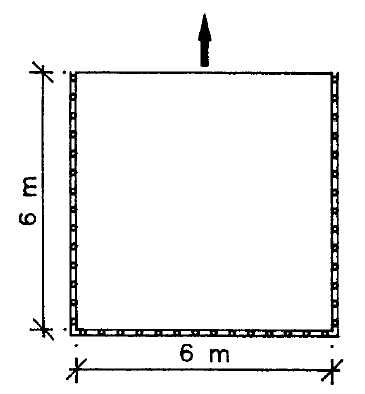

# List input file

In [ ]:
!cat squa4.dat

SQUARE PLATE UNDER TIME-HARMONIC TRACTION (4 QUADRATIC ELEMENTS)
 24,5,3,76923076923.1,0.05,7850.0,0.30
 10.0 40.0 70.0
 0.0  0.0 6.0  0.0 6.0  6.0 0.0  6.0 1.0  0.0 2.0  0.0 3.0  0.0 4.0  0.0 5.0  0.0 0.5  0.0 1.5  0.0 2.5  0.0 3.5  0.0 4.5  0.0 5.5  0.0 6.0  1.0 6.0  2.0 6.0  3.0 6.0  4.0 6.0  5.0 6.0  0.5 6.0  1.5 6.0  2.5 6.0  3.5 6.0  4.5 6.0  5.5 5.0  6.0 4.0  6.0 3.0  6.0 2.0  6.0 1.0  6.0 5.5  6.0 4.5  6.0 3.5  6.0 2.5  6.0 1.5  6.0 0.5  6.0 0.0  5.0 0.0  4.0 0.0  3.0 0.0  2.0 0.0  1.0 0.0  5.5 0.0  4.5 0.0  3.5 0.0  2.5 0.0  1.5 0.0  0.5
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0.0)
 0 (0.0,0.0)   0 (0.0,0.0)   0 (0.0,0.0)
 1 (0.0,0.0)   1 (0.0,0.0)   1 (0.0,0

(1) Title Line. Contains the title of the problem.

(2) Basic Parameter Line. Contains the number of elements, number of internal points, the number of frequencies to be analyzed, the real part of the shear modulus, the internal damping ratio, the density and the Poisson's ratio (or fictitious Poisson's ratio for plane stress problems $\left.v^{\prime}=v /(1+v)\right)$.

(3) Frequencies Line. One or more lines containing the values of the frequencies to be studied which are read in free FORMAT.

(4) Boundary Nodes Coordinates Lines. The coordinates are read counter-clockwise for external boundaries and clockwise for internal ones.

(5) Boundary Conditions Lines. Two lines of boundary conditions are read for each element; one line for each direction $x_1, x_2$. Three variables and three values of KODE corresponding to the three nodes are read in each line. The known variables are the displacement if $\mathrm{KODE}=0$ and the traction if $\mathrm{KODE}=1$. Nodes at the extreme of the elements may have a value of the traction prescribed as part of one element and a different value as part of the other. The displacement must be unique for any node.

(6) Internal Points Coordinates Lines. The $x_1 x_2$ coordinates for each point are read in free FORMAT. There will be one or more lines, if necessary.

# List output file

In [ ]:
cat squa4.out

 *******************************************************************************
SQUARE PLATE UNDER TIME-HARMONIC TRACTION (4 QUADRATIC ELEMENTS)                


 DATA

  NUMBER OF BOUNDARY ELEMENTS = 24
  NUMBER OF INTERNAL POINTS =  5
  NUMBER OF FREQUENCIES =  3
  P-WAVE VELOCITY=  5863.655    ,  292.4534    
  S-WAVE VELOCITY=  3134.255    ,  156.3229    
  SHEAR MODULUS= 0.7692308E+11, 0.7692308E+10
  DAMPING RATIO= 0.5000000E-01
  DENSITY=  7850.000    
  POISSON RATIO= 0.3000000    

  FREQUENCIES
    10.00000        40.00000        70.00000    


  BOUNDARY NODES COORDINATES


    NODE          X                  Y

       1      0.0000000E+00      0.0000000E+00
       2      0.6000000E+01      0.0000000E+00
       3      0.6000000E+01      0.6000000E+01
       4      0.0000000E+00      0.6000000E+01
       5      0.1000000E+01      0.0000000E+00
       6      0.2000000E+01      0.0000000E+00
       7      0.3000000E+01      0.0000000E+00
       8      0.4000000E+01      0.00

The analytical solution for this one-dimensional P-wave propagation problem with perfectly elastic material gives resonance frequencies at $\omega=(2 \mathrm{n}+$ 1) $\pi \mathrm{c}_1 /(2 \mathrm{~L})=45.345,1369.035,226.785 \ldots \mathrm{~s}^{-1}$. The problem is solved numerically for a frequency range from 0 to $150 \mathrm{~s}^{-1}$ using twelve equal constant elements (three per side) and four equal quadratic elements (one per side) (Figure below) by the codes CONDPLEH and QUADPLEH, respectively.

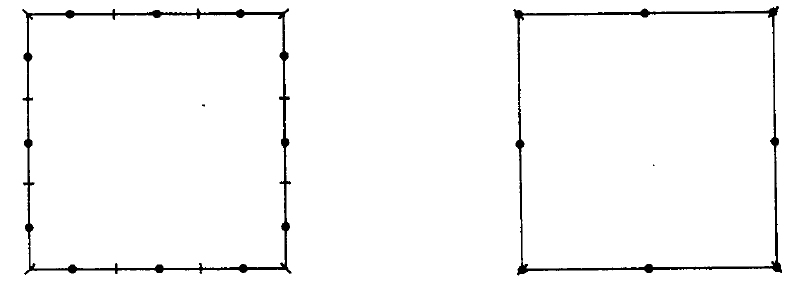

The amplitude of the displacement normal to the boundary at the node located at mid point of the loaded side is shown versus the normalized frequency ( $\omega / \omega_1$, with $\omega_1=45.345 \mathrm{~s}^{-1}$ ) in Figure below.

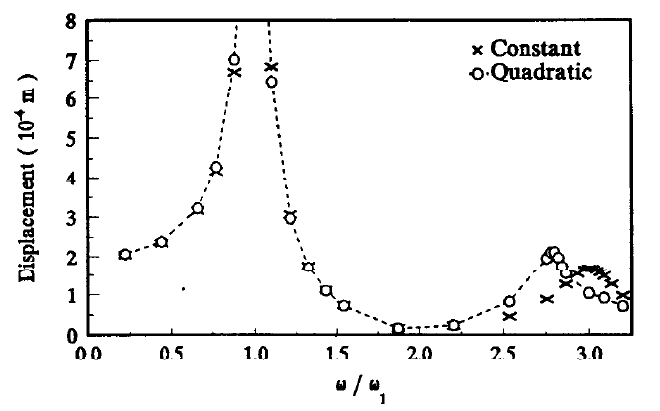

Figure 2.26. Modulus of the vertical displacement at the upper side versus dimensionless frequency

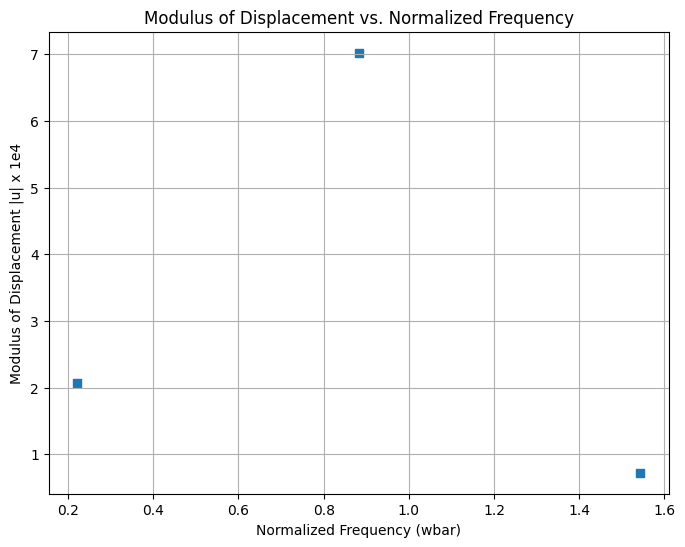

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

w1 = 45.345
w = np.array([10., 40., 70.])
wbar = w / w1

# The provided 'u' array has real and imaginary parts in separate columns
# Convert it to a complex numpy array
u_real = np.array([0.2061E-03, 0.6452E-03, -0.7101E-04])
u_imag = np.array([-0.2149E-04, -0.2769E-03, -0.1365E-04])
u_complex = u_real + 1j * u_imag

# Calculate the modulus of u_complex
u_modulus = np.abs(u_complex)

# Plot the modulus of u versus wbar (normalized frequencies)
plt.figure(figsize=(8, 6))
plt.scatter(wbar, u_modulus*1e4,marker='s')
plt.xlabel('Normalized Frequency (wbar)')
plt.ylabel('Modulus of Displacement |u| x 1e4')
plt.title('Modulus of Displacement vs. Normalized Frequency')
plt.grid(True)
plt.show()

Results for the two types of elements are shown. The computed real part of the displacements at internal points along the central axis of the domain are shown in Figure 2.27 for three significant frequencies. The results in Figures 2.26 and 2.27 are in good agreement with the analytical solution and show that both meshes and type of elements are adequate for this simple problem.

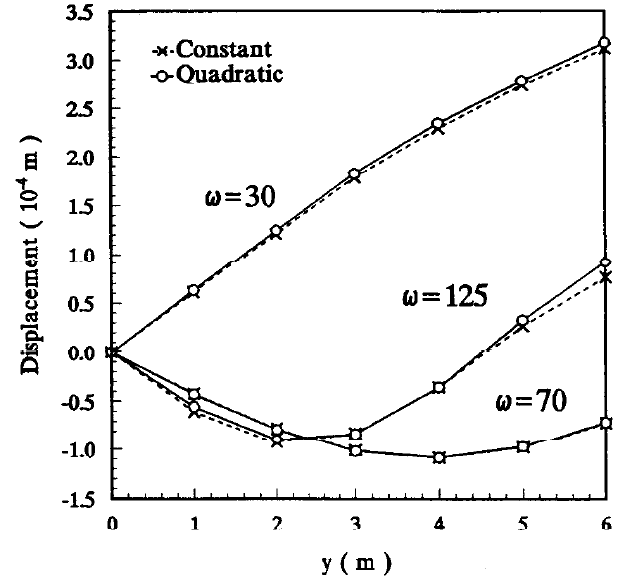

Figure 2.27. Real part of the vertical displacements at internal points

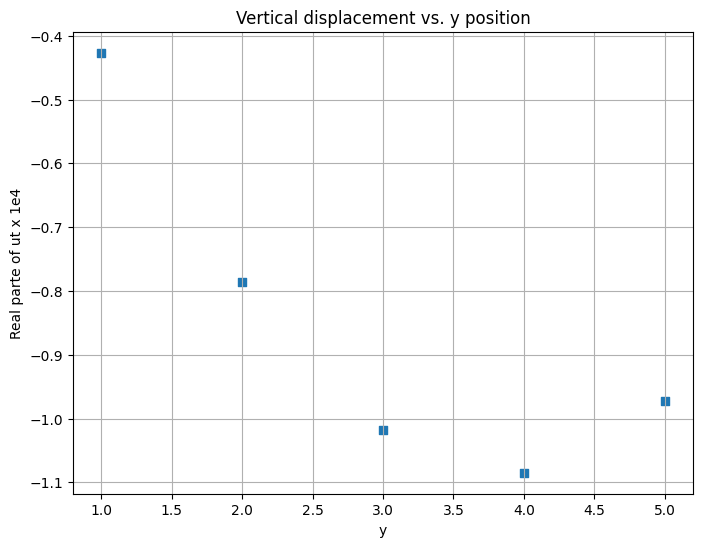

In [ ]:
y=np.array([1.,2.,3.,4.,5.])
uyreal = np.array([-0.4265E-04,-0.7852E-04,-0.1018E-03, -0.1085E-03,-0.9723E-04])
# Plot the modulus of u versus wbar (normalized frequencies)
plt.figure(figsize=(8, 6))
plt.scatter(y, uyreal*1e4,marker='s')
plt.xlabel('y')
plt.ylabel('Real parte of ut x 1e4')
plt.title('Vertical displacement vs. y position')
plt.grid(True)
plt.show()